# Single Neuron with Different Activation Functions

**Unit:** Unit 4: Neural Networks Fundamentals

Every artificial neuron does the same two-step job: compute a weighted sum of its
inputs plus a bias, then pass that score through an **activation function**. Keras
lets you pick `sigmoid`, `tanh`, `relu`, and more — so which one should you choose,
and how much does the choice actually change what a neuron can learn? Instead of
memorizing rules of thumb, we run the experiment: we train the **same single neuron**
on the **same 2D dataset** three times, changing only the activation, and compare the
accuracies and decision boundaries side by side.

## 📚 Learning Objectives

By completing this notebook, you will:
- Plot and compare the sigmoid, tanh, and ReLU activation curves
- Build a single-neuron model in Keras: `Dense(1)` with a chosen activation
- Train the same neuron with each activation on the same dataset (change one thing at a time)
- Compare accuracies and decision boundaries in one figure — and explain what the activation can and cannot change

---

## 1. The Three Classic Activations

The activation function decides how the neuron's raw score `z = w·x + b` becomes an output:

| Activation | Formula | Output range |
|---|---|---|
| Sigmoid | `1 / (1 + e^-z)` | (0, 1) |
| Tanh | `tanh(z)` | (-1, 1) |
| ReLU | `max(0, z)` | [0, ∞) |

Before training anything, let's look at their shapes. Notice that all three are
**monotonic**: as `z` grows, the output never decreases. Keep that in mind — it will
explain the decision boundaries we see later.

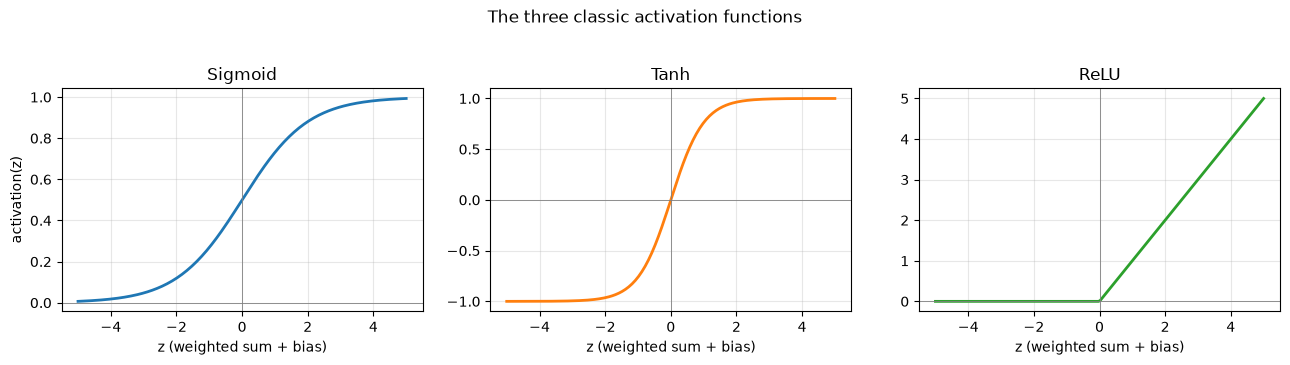

Output at a few sample scores:
     z |  sigmoid |    tanh |  relu
  -3.0 |    0.047 |  -0.995 |   0.0
  -1.0 |    0.269 |  -0.762 |   0.0
   0.0 |    0.500 |   0.000 |   0.0
   1.0 |    0.731 |   0.762 |   1.0
   3.0 |    0.953 |   0.995 |   3.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, curve, name, color in zip(
        axes, [sigmoid, tanh, relu], ["Sigmoid", "Tanh", "ReLU"],
        ["tab:blue", "tab:orange", "tab:green"]):
    ax.plot(z, curve, color=color, linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_title(name)
    ax.set_xlabel("z (weighted sum + bias)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("activation(z)")
plt.suptitle("The three classic activation functions", y=1.03)
plt.tight_layout()
plt.show()

print("Output at a few sample scores:")
print(f"{'z':>6} | {'sigmoid':>8} | {'tanh':>7} | {'relu':>5}")
for zi in [-3.0, -1.0, 0.0, 1.0, 3.0]:
    print(f"{zi:>6.1f} | {1/(1+np.exp(-zi)):>8.3f} | {np.tanh(zi):>7.3f} | {max(0.0, zi):>5.1f}")

## 2. The Dataset: Two Interleaving Moons

We need a dataset where the right answer is **not** a straight line, so we can see
whether changing the activation helps a single neuron handle a curved class
boundary. `make_moons` from scikit-learn generates two crescent-shaped classes that
curve around each other — small, 2D, and easy to visualize.

Total samples : 300  (2 features each)
Training set  : 200 samples
Test set      : 100 samples
Class balance : [150 150] (class 0, class 1)


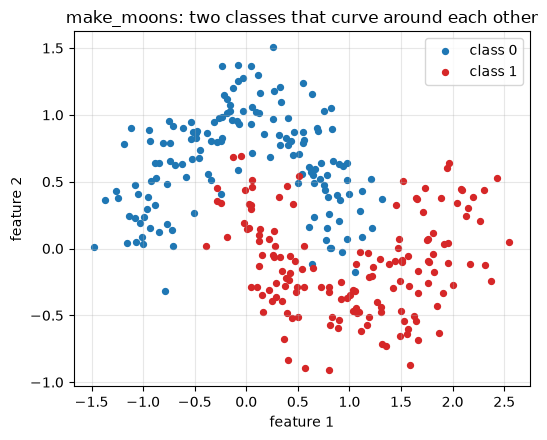

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=100, random_state=42, stratify=y)

print(f"Total samples : {len(X)}  (2 features each)")
print(f"Training set  : {len(X_train)} samples")
print(f"Test set      : {len(X_test)} samples")
print(f"Class balance : {np.bincount(y)} (class 0, class 1)")

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="tab:blue", s=18, label="class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="tab:red", s=18, label="class 1")
plt.title("make_moons: two classes that curve around each other")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. The Experiment: Same Neuron, Three Activations

Our model is as small as a neural network can get: **one `Dense(1)` layer** — a
single neuron with 2 weights and 1 bias (3 trainable parameters). We train it three
times, and between runs we change **only the activation function**. Everything else
is fixed:

- same data and same train/test split,
- same loss (mean squared error against the 0/1 labels — it works for all three
  output ranges, so the comparison stays fair),
- same optimizer, epochs, and random seed.

The predicted class is `1` when the neuron's output is above 0.5, else `0`.

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

ACTIVATIONS = ["sigmoid", "tanh", "relu"]
results = {}

def train_single_neuron(activation):
    keras.utils.set_random_seed(42)   # identical initialization for every run
    model = Sequential([
        Input(shape=(2,)),
        Dense(1, activation=activation),
    ])
    model.compile(optimizer=Adam(learning_rate=0.05), loss="mse")
    model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)
    return model

def accuracy(model, X_, y_):
    preds = (model.predict(X_, verbose=0).ravel() > 0.5).astype(int)
    return (preds == y_).mean()

print("Training one single-neuron model per activation (150 epochs each)...\n")
print(f"{'activation':<10} | {'params':>6} | {'train acc':>9} | {'test acc':>8}")
print("-" * 44)
for act in ACTIVATIONS:
    model = train_single_neuron(act)
    tr, te = accuracy(model, X_train, y_train), accuracy(model, X_test, y_test)
    results[act] = {"model": model, "train_acc": tr, "test_acc": te}
    print(f"{act:<10} | {model.count_params():>6} | {tr:>9.3f} | {te:>8.3f}")

Training one single-neuron model per activation (150 epochs each)...

activation | params | train acc | test acc
--------------------------------------------


sigmoid    |      3 |     0.880 |    0.860


tanh       |      3 |     0.870 |    0.850


relu       |      3 |     0.880 |    0.860


## 4. Decision Boundaries — One Figure, Three Activations

Accuracy numbers alone don't show *how* each neuron divides the plane. Below we
color the plane by each model's predicted class and overlay the test points. Watch
the **shape of the border** between the two colored regions in each panel.

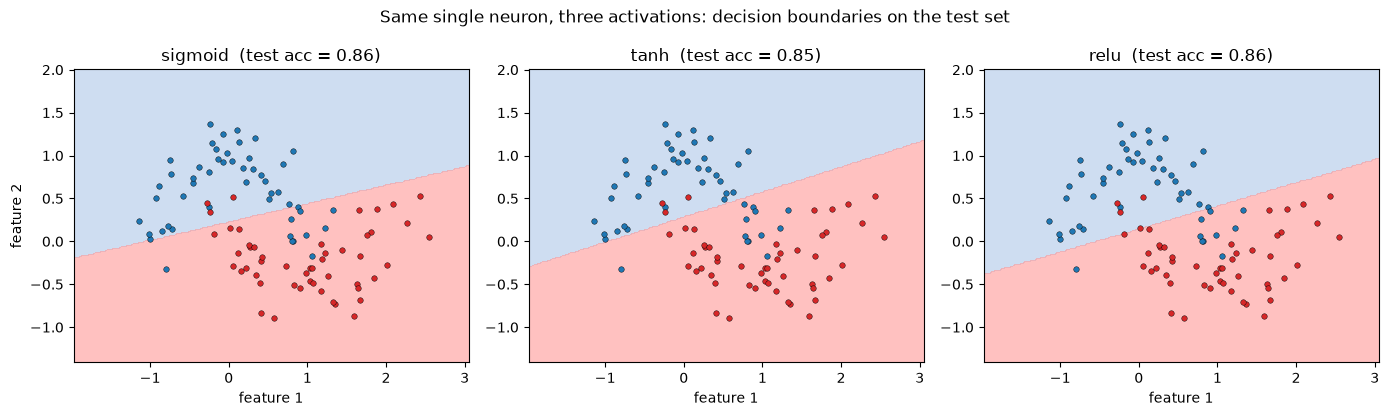

Test accuracies: sigmoid=0.860, tanh=0.850, relu=0.860
Spread between best and worst activation: 0.010

Every panel shows a STRAIGHT-LINE border between the two regions:
a single neuron's boundary is where w1*x1 + w2*x2 + b crosses a fixed
threshold, and a monotonic activation cannot bend that line.


In [4]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, act in zip(axes, ACTIVATIONS):
    zz = (results[act]["model"].predict(grid, verbose=0).ravel() > 0.5)
    zz = zz.astype(int).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5],
                colors=["#aec7e8", "#ff9896"], alpha=0.6)
    ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
               c="tab:blue", s=16, edgecolors="k", linewidths=0.3)
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
               c="tab:red", s=16, edgecolors="k", linewidths=0.3)
    ax.set_title(f"{act}  (test acc = {results[act]['test_acc']:.2f})")
    ax.set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")
plt.suptitle("Same single neuron, three activations: decision boundaries on the test set")
plt.tight_layout()
plt.show()

accs = [results[a]["test_acc"] for a in ACTIVATIONS]
print(f"Test accuracies: " +
      ", ".join(f"{a}={results[a]['test_acc']:.3f}" for a in ACTIVATIONS))
print(f"Spread between best and worst activation: {max(accs) - min(accs):.3f}")
print("\nEvery panel shows a STRAIGHT-LINE border between the two regions:")
print("a single neuron's boundary is where w1*x1 + w2*x2 + b crosses a fixed")
print("threshold, and a monotonic activation cannot bend that line.")

---

## ✅ Summary

**What the outputs actually show:**

- All three activations land within **one percentage point** of each other:
  test accuracy 0.86 (sigmoid), 0.85 (tanh), 0.86 (relu).
- All three decision boundaries are **straight lines**. Changing the activation
  tilted the line slightly, but never bent it around the moons — so roughly the
  same points get misclassified in every panel.

**Why:** a single neuron computes one linear score `z = w·x + b`, and classifying by
thresholding a *monotonic* activation of `z` is the same as thresholding `z` itself.
So the activation changes the output's *range* and the training dynamics — but with
one neuron, the boundary stays linear no matter which activation you pick.

**The takeaway:** the moons dataset needs a *curved* boundary, and no activation
choice can give a lone neuron one. The fix is **more neurons in hidden layers**,
where activations become essential — stacking purely linear layers would collapse
back into one straight line. That is exactly where the next notebook picks up.

---